<a href="https://colab.research.google.com/github/tharushidambarage/BioLens-AI-Facial-Analyzer/blob/notebooks/01_preprocessing_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BioLens – Notebook 01: Data Collection and Preprocessing

**Project:** AI Facial Attribute & Geometry Analyzer

This notebook downloads the datasets, preprocesses facial images,
creates a balanced BioLens subset, and prepares labels for PyTorch training.

In [1]:
import torch

print(torch.__version__)
print("GPU:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.11.0+cu128
GPU: True
Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

BASE_PATH = "/content/drive/MyDrive/BioLens"

print("BioLens exists:", os.path.exists(BASE_PATH))

BioLens exists: True


In [4]:
import os

BASE_PATH = "/content/drive/MyDrive/BioLens"

folders = [
    "datasets",
    "models",
    "outputs",
    "notebooks",
    "report",
    "presentation",
    "flutter_app"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_PATH, folder), exist_ok=True)

print("✅ BioLens folder structure created.")

✅ BioLens folder structure created.


In [5]:
for folder in sorted(os.listdir(BASE_PATH)):
    print("📁", folder)

📁 datasets
📁 flutter_app
📁 models
📁 notebooks
📁 outputs
📁 presentation
📁 report


# Every notebook starts with one configuration cell:

from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/BioLens"

DATASET_PATH = f"{BASE_PATH}/datasets"
MODEL_PATH = f"{BASE_PATH}/models"
OUTPUT_PATH = f"{BASE_PATH}/outputs"

In [6]:
import json
import os

kaggle_credentials = {
    "username": "tharushidambarage",
    "key": "KGAT_eeb56e1cf8b59c3a0456f6208fbb2e6d"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [7]:
!kaggle datasets list -s celeba

ref                                                   title                                               size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------  -------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
jessicali9530/celeba-dataset                          CelebFaces Attributes (CelebA) Dataset        1427750792  2018-06-01 20:08:48.043000         242297       1871  0.7647059        
kushsheth/face-vae                                    CelebA Dataset                                1427750792  2024-04-25 16:50:56.483000           2928         20  0.88235295       
badasstechie/celebahq-resized-256x256                 CelebA-HQ resized (256x256)                    296807591  2021-04-30 14:24:53.643000          19811         88  0.75             
quadeer15sh/celeba-face-recognition-triplets          CelebA Face Recognition Tr

In [8]:
# Move to Colab working directory
%cd /content

# Download CelebA dataset from Kaggle
!kaggle datasets download -d jessicali9530/celeba-dataset

/content
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:11<00:00, 129MB/s]



In [9]:
import os

print("ZIP exists:", os.path.exists("/content/celeba-dataset.zip"))
print("ZIP size (GB):", round(os.path.getsize("/content/celeba-dataset.zip")/1024**3,2))

ZIP exists: True
ZIP size (GB): 1.33


In [10]:
# Extracting only 5000 images

In [12]:
!unzip -j /content/celeba-dataset.zip "list_attr_celeba.csv" -d /content/celeba_metadata

Archive:  /content/celeba-dataset.zip
  inflating: /content/celeba_metadata/list_attr_celeba.csv  


In [13]:
import pandas as pd

attr = pd.read_csv("/content/celeba_metadata/list_attr_celeba.csv")

labels = attr[[
    "image_id",
    "Black_Hair",
    "Brown_Hair",
    "Blond_Hair",
    "Eyeglasses"
]].copy()

# Convert -1 to 0
labels.replace(-1, 0, inplace=True)

# Keep only images with black, brown or blond hair
labels = labels[
    (labels.Black_Hair == 1) |
    (labels.Brown_Hair == 1) |
    (labels.Blond_Hair == 1)
]

# Random balanced subset
labels = labels.sample(5000, random_state=42)

print(labels.shape)
labels.head()

(5000, 5)


,image_id,Black_Hair,Brown_Hair,Blond_Hair,Eyeglasses
1648,001649.jpg,1,0,0,0
58808,058809.jpg,0,1,0,0
76033,076034.jpg,0,1,0,0
112060,112061.jpg,0,1,0,0
39206,039207.jpg,1,0,0,0


In [15]:
import os

BASE_PATH = "/content/drive/MyDrive/BioLens"

DATASET_PATH = os.path.join(BASE_PATH, "datasets")

CELEBA_PATH = os.path.join(DATASET_PATH, "celeba_subset")
CELEBA_IMAGE_PATH = os.path.join(CELEBA_PATH, "images")

FITZ_PATH = os.path.join(DATASET_PATH, "fitzpatrick17k")
FITZ_IMAGE_PATH = os.path.join(FITZ_PATH, "images")

# Create folders
for folder in [CELEBA_PATH, CELEBA_IMAGE_PATH, FITZ_PATH, FITZ_IMAGE_PATH]:
    os.makedirs(folder, exist_ok=True)

print("✅ Dataset folders created.")

✅ Dataset folders created.


In [16]:
labels.to_csv(
    os.path.join(CELEBA_PATH, "labels.csv"),
    index=False
)

print("✅ labels.csv saved.")

✅ labels.csv saved.


In [21]:
import zipfile
import os
from tqdm import tqdm

zip_path = "/content/celeba-dataset.zip"

# Make sure destination folder exists
os.makedirs(CELEBA_IMAGE_PATH, exist_ok=True)

selected_images = set(labels["image_id"])
count = 0

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    for member in tqdm(zip_ref.namelist()):

        # Get only the filename (000001.jpg)
        filename = os.path.basename(member)

        if filename in selected_images:

            with zip_ref.open(member) as source:
                with open(os.path.join(CELEBA_IMAGE_PATH, filename), "wb") as target:
                    target.write(source.read())

            count += 1

print(f"✅ Extracted {count} images into {CELEBA_IMAGE_PATH}")

100%|██████████| 202603/202603 [00:42<00:00, 4726.13it/s]

✅ Extracted 5000 images into /content/drive/MyDrive/BioLens/datasets/celeba_subset/images


In [23]:
import shutil
import glob

source = os.path.join(CELEBA_IMAGE_PATH, "img_align_celeba")

if os.path.exists(source):
    for img in glob.glob(os.path.join(source, "*.jpg")):
        shutil.move(img, CELEBA_IMAGE_PATH)

    shutil.rmtree(source)

print("✅ Images moved into images folder.")

✅ Images moved into images folder.


In [24]:
import glob

images = glob.glob(os.path.join(CELEBA_IMAGE_PATH, "*.jpg"))

print("Total images:", len(images))

print("First five images:")
for img in images[:5]:
    print(os.path.basename(img))

Total images: 5000
First five images:
000070.jpg
000141.jpg
000181.jpg
000208.jpg
000212.jpg


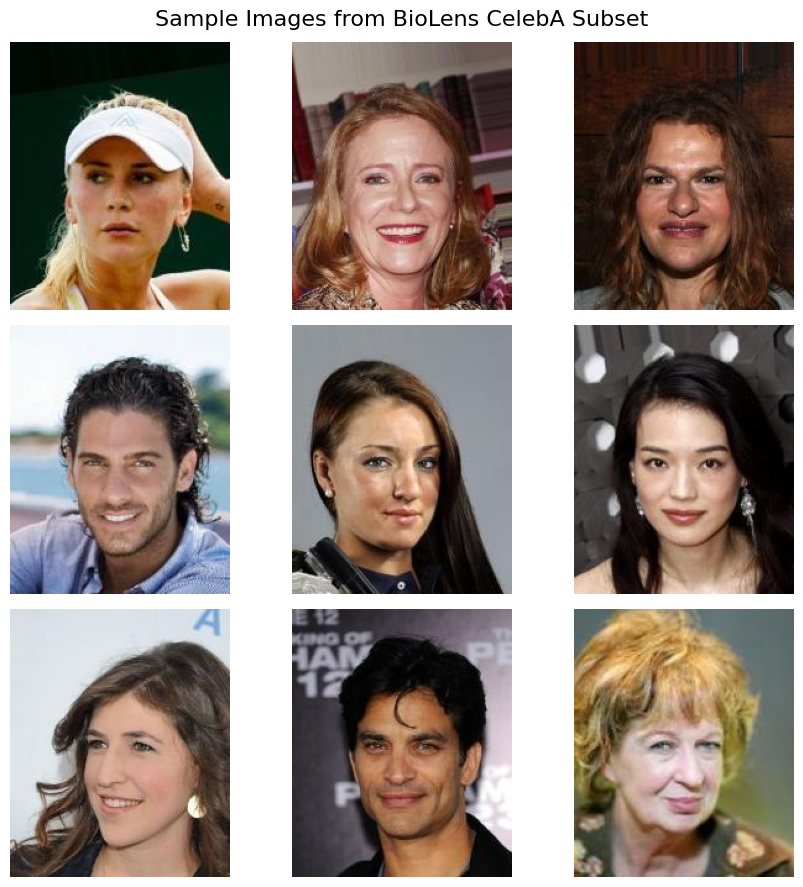

In [25]:
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_images = random.sample(images, 9)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for ax, img_path in zip(axes.flat, sample_images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Sample Images from BioLens CelebA Subset", fontsize=16)
plt.tight_layout()
plt.show()

# **Clean Labels & Prepare PyTorch Dataset**

In [26]:
# Create readable labels

def get_hair_color(row):
    if row["Black_Hair"] == 1:
        return "Black"
    elif row["Brown_Hair"] == 1:
        return "Brown"
    elif row["Blond_Hair"] == 1:
        return "Blond"
    else:
        return "Unknown"

labels["hair_color"] = labels.apply(get_hair_color, axis=1)

labels["eyeglasses"] = labels["Eyeglasses"].map({
    0: "No",
    1: "Yes"
})

labels.head()

,image_id,Black_Hair,Brown_Hair,Blond_Hair,Eyeglasses,hair_color,eyeglasses
1648,001649.jpg,1,0,0,0,Black,No
58808,058809.jpg,0,1,0,0,Brown,No
76033,076034.jpg,0,1,0,0,Brown,No
112060,112061.jpg,0,1,0,0,Brown,No
39206,039207.jpg,1,0,0,0,Black,No


In [27]:
labels_clean = labels[
    ["image_id", "hair_color", "eyeglasses"]
].copy()

labels_clean.head()

,image_id,hair_color,eyeglasses
1648,001649.jpg,Black,No
58808,058809.jpg,Brown,No
76033,076034.jpg,Brown,No
112060,112061.jpg,Brown,No
39206,039207.jpg,Black,No


In [28]:
labels_clean.to_csv(
    os.path.join(CELEBA_PATH, "labels.csv"),
    index=False
)

print("✅ Final labels.csv saved.")

✅ Final labels.csv saved.


In [29]:
import pandas as pd

check = pd.read_csv(os.path.join(CELEBA_PATH, "labels.csv"))
check.head()

,image_id,hair_color,eyeglasses
0,001649.jpg,Black,No
1,058809.jpg,Brown,No
2,076034.jpg,Brown,No
3,112061.jpg,Brown,No
4,039207.jpg,Black,No


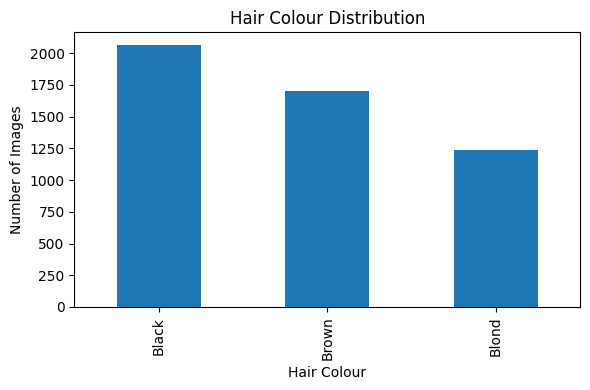

In [30]:
import matplotlib.pyplot as plt

hair_counts = labels_clean["hair_color"].value_counts()

plt.figure(figsize=(6,4))
hair_counts.plot(kind="bar")

plt.title("Hair Colour Distribution")
plt.xlabel("Hair Colour")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [31]:
plt.savefig(
    os.path.join(BASE_PATH, "outputs/hair_distribution.png"),
    dpi=300
)

<Figure size 640x480 with 0 Axes>

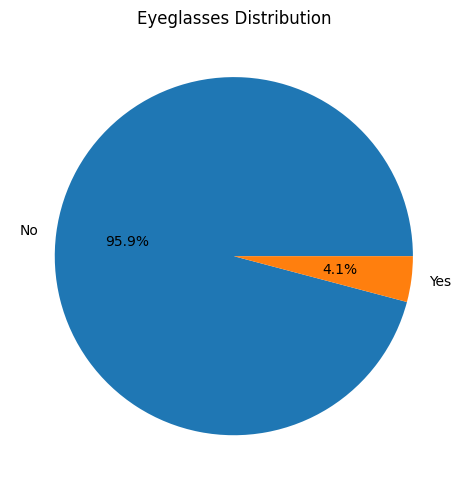

In [32]:
glass_counts = labels_clean["eyeglasses"].value_counts()

plt.figure(figsize=(5,5))

glass_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Eyeglasses Distribution")

plt.tight_layout()
plt.show()

In [33]:
plt.savefig(
    os.path.join(BASE_PATH, "outputs/glasses_distribution.png"),
    dpi=300
)

<Figure size 640x480 with 0 Axes>

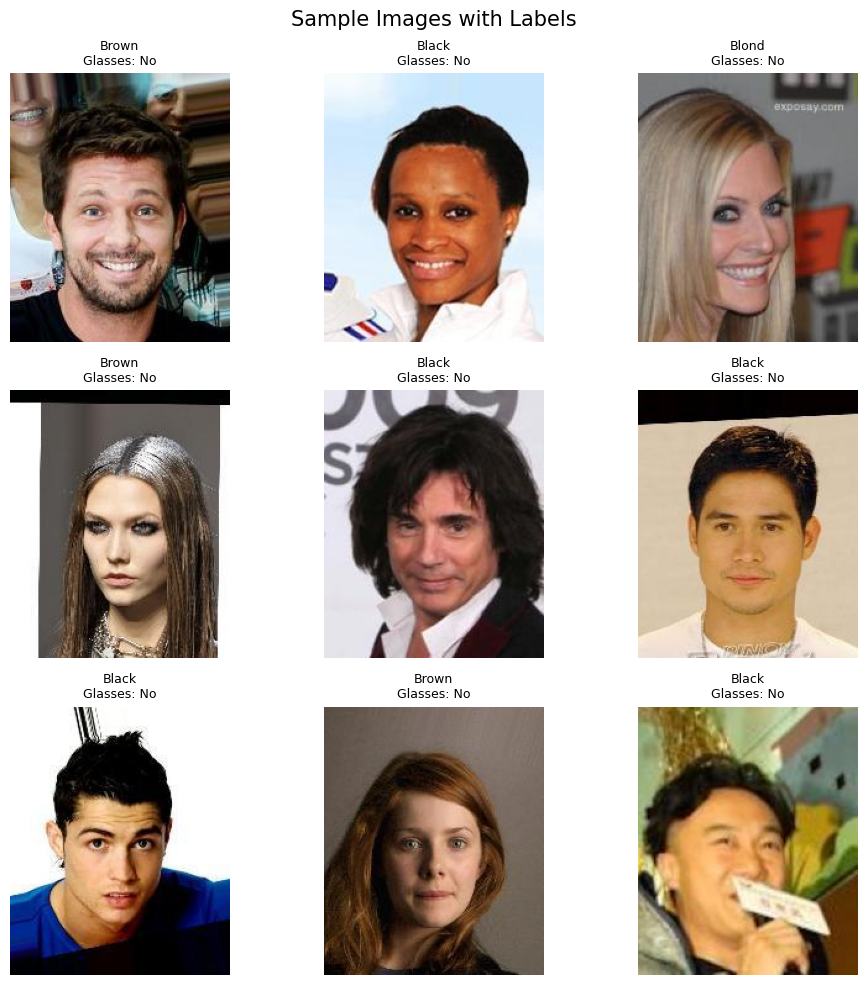

In [34]:
import random
from PIL import Image
import matplotlib.pyplot as plt

sample_df = labels_clean.sample(9, random_state=42)

fig, axes = plt.subplots(3,3, figsize=(10,10))

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):

    img = Image.open(
        os.path.join(
            CELEBA_IMAGE_PATH,
            row["image_id"]
        )
    )

    ax.imshow(img)
    ax.axis("off")

    ax.set_title(
        f'{row["hair_color"]}\nGlasses: {row["eyeglasses"]}',
        fontsize=9
    )

plt.suptitle("Sample Images with Labels", fontsize=15)

plt.tight_layout()
plt.show()

In [35]:
plt.savefig(
    os.path.join(BASE_PATH, "outputs/sample_images_labels.png"),
    dpi=300
)

<Figure size 640x480 with 0 Axes>

Train / Validation / Test Spli

In [36]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    labels_clean,
    test_size=0.30,
    random_state=42,
    stratify=labels_clean["hair_color"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["hair_color"]
)

print("Training :", len(train_df))
print("Validation :", len(val_df))
print("Testing :", len(test_df))

Training : 3500
Validation : 750
Testing : 750


In [37]:
train_df.to_csv(
    os.path.join(CELEBA_PATH, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(CELEBA_PATH, "val.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(CELEBA_PATH, "test.csv"),
    index=False
)

print("✅ Dataset splits saved.")

✅ Dataset splits saved.


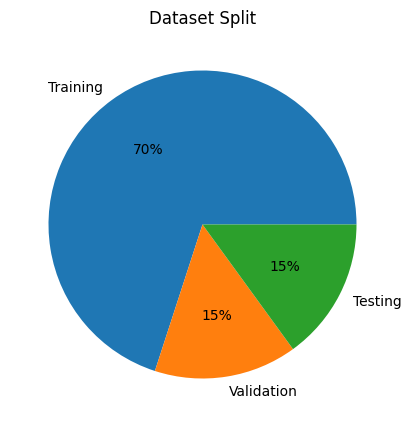

In [38]:
sizes = [len(train_df), len(val_df), len(test_df)]
labels_names = ["Training","Validation","Testing"]

plt.figure(figsize=(5,5))

plt.pie(
    sizes,
    labels=labels_names,
    autopct="%1.0f%%"
)

plt.title("Dataset Split")

plt.show()

In [39]:
plt.savefig(
    os.path.join(BASE_PATH, "outputs/dataset_split.png"),
    dpi=300
)

<Figure size 640x480 with 0 Axes>

In [40]:
print("="*40)
print("BioLens CelebA Dataset Summary")
print("="*40)

print("Total Images :", len(labels_clean))
print("Training Images :", len(train_df))
print("Validation Images :", len(val_df))
print("Testing Images :", len(test_df))

print("\nHair Colour Classes")
print(labels_clean["hair_color"].value_counts())

print("\nEyeglasses Classes")
print(labels_clean["eyeglasses"].value_counts())

BioLens CelebA Dataset Summary
Total Images : 5000
Training Images : 3500
Validation Images : 750
Testing Images : 750

Hair Colour Classes
hair_color
Black    2062
Brown    1704
Blond    1234
Name: count, dtype: int64

Eyeglasses Classes
eyeglasses
No     4794
Yes     206
Name: count, dtype: int64
